# **Analítica Computacional para la toma de Decisiones Avanzada – Taller 5 202610**

## Regresión con redes neuronales

Tome como base el modelo de redes neuronales (usando Tensorflow) presentado en el cuaderno de la clase para predecir el consumo de gasolina (MPG) a partir de los datos auto-mpg.data que encontrará en Bloque Neón.

---

Daniel Benavides - 202220428 - <d.benavidess@uniandes.edu.co>

Juanita Cortés - 202222129 - <jv.cortesv1@uniandes.edu.co>

In [1]:
import numpy as np
import pandas as pd

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_csv('auto-mpg.data',
                 names=['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                        'Acceleration', 'Model Year', 'Origin'],
                 sep=' ',
                 na_values='?',
                 comment='\t',
                 skipinitialspace=True)

df.dropna(inplace=True)
print(df.shape)
df.head()

(392, 8)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


## Punto 1.

En un nuevo cuaderno, cree un modelo de redes neuronales que emplee 4 de las variables/características disponibles en el conjunto de datos para predecir MPG. Defina una arquitectura inicial con una capa de normalización y una capa oculta con un número de neuronas de su elección. En su reporte grafique la arquitectura de la red, incluya el número de parámetros a estimar y justifique este número.

In [3]:
# Seleccionar solo las 4 variables de interés + target
variables = ['Horsepower', 'Displacement', 'Weight', 'Acceleration']
target = 'MPG'

df_model = df[variables + [target]].copy()
print(df_model.shape)
df_model.head()

(392, 5)


,Horsepower,Displacement,Weight,Acceleration,MPG
0,130.0,307.0,3504.0,12.0,18.0
1,165.0,350.0,3693.0,11.5,15.0
2,150.0,318.0,3436.0,11.0,18.0
3,150.0,304.0,3433.0,12.0,16.0
4,140.0,302.0,3449.0,10.5,17.0


In [4]:
train = df_model.sample(frac=0.8, random_state=100)
test  = df_model.drop(train.index)

print(f'Train: {train.shape} | Test: {test.shape}')

train_X = train[variables].copy()
test_X  = test[variables].copy()
train_y = train[target].copy()
test_y  = test[target].copy()

Train: (314, 5) | Test: (78, 5)


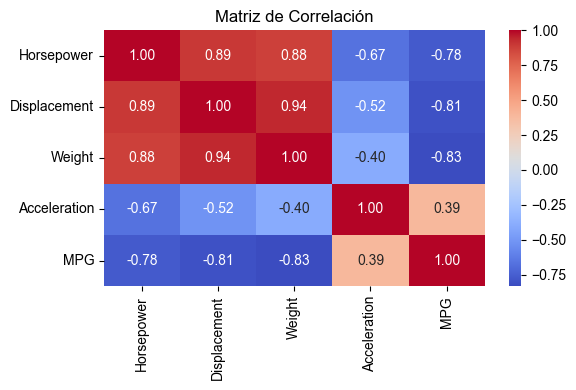

In [5]:
# Correlación
plt.figure(figsize=(6, 4))
sns.heatmap(train[variables + [target]].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [6]:
def plot_loss(history, title='Historial de Pérdida'):
    """Grafica pérdida de entrenamiento y validación."""
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.xlabel('Época')
    plt.ylabel('MAE [MPG]')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, name, results_dict):
    """Evalúa el modelo en test y guarda el resultado."""
    mae = model.evaluate(test_X, test_y, verbose=0)
    results_dict[name] = mae
    print(f'{name:40s} → MAE en test: {mae:.4f}')
    return mae

def build_and_train(layers_config, name, epochs=200, lr=0.001):
    """
    Construye, compila y entrena un modelo Sequential.
    layers_config: lista de capas Keras (sin normalización, se agrega automáticamente).
    """
    norm = tf.keras.layers.Normalization(axis=-1)
    norm.adapt(np.array(train_X))

    model = tf.keras.Sequential([norm] + layers_config)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mean_absolute_error'
    )
    history = model.fit(
        train_X, train_y,
        validation_split=0.2,
        epochs=epochs,
        verbose=0
    )
    return model, history

# Diccionario global de resultados
results = {}

In [7]:
import tensorflow as tf
from tensorflow import keras

In [8]:
norm_base = tf.keras.layers.Normalization(axis=-1)
norm_base.adapt(np.array(train_X))

base_model = tf.keras.Sequential([
    norm_base,
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])

base_model.build(input_shape=(None, 4))
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 4)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 9 (40.00 B)

In [9]:
tf.keras.utils.plot_model(
    base_model,
    to_file='arquitectura_base.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR',
    expand_nested=True
)



You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## Punto 2.

Entrene este modelo (éste es su modelo base), grafique el historial de pérdida de entrenamiento y validación, y comente sus resultados en su reporte.

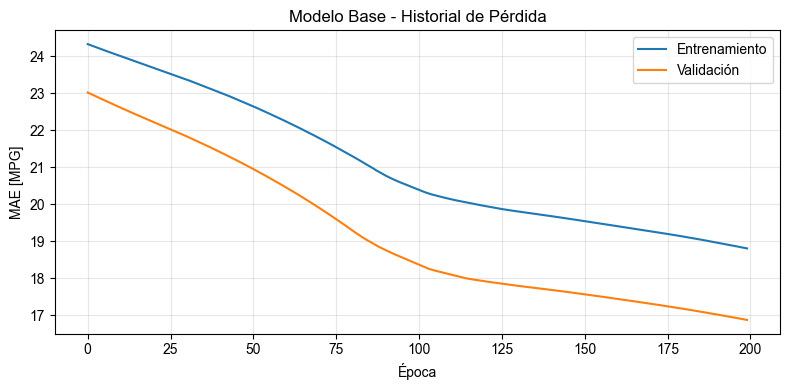

Base (2 neuronas, ReLU, 1 capa)          → MAE en test: 17.5925


17.592510223388672

In [10]:
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mean_absolute_error'
)

history_base = base_model.fit(
    train_X, train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

plot_loss(history_base, title='Modelo Base - Historial de Pérdida')
evaluate_model(base_model, 'Base (2 neuronas, ReLU, 1 capa)', results)

## Punto 3.

Modifique el número de neuronas en la capa oculta (3 casos diferentes al modelo base), entrene los modelos resultantes y compare. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte.

In [11]:
neuron_configs = {
    '8 neuronas':  8,
    '64 neuronas': 64,
    '128 neuronas': 128
}

histories_neurons = {}

for name, n in neuron_configs.items():
    model, hist = build_and_train(
        [tf.keras.layers.Dense(n, activation='relu'),
         tf.keras.layers.Dense(1)],
        name
    )
    histories_neurons[name] = hist
    evaluate_model(model, f'Neuronas: {name}', results)

Neuronas: 8 neuronas                     → MAE en test: 3.6604
Neuronas: 64 neuronas                    → MAE en test: 2.7571
Neuronas: 128 neuronas                   → MAE en test: 2.6887


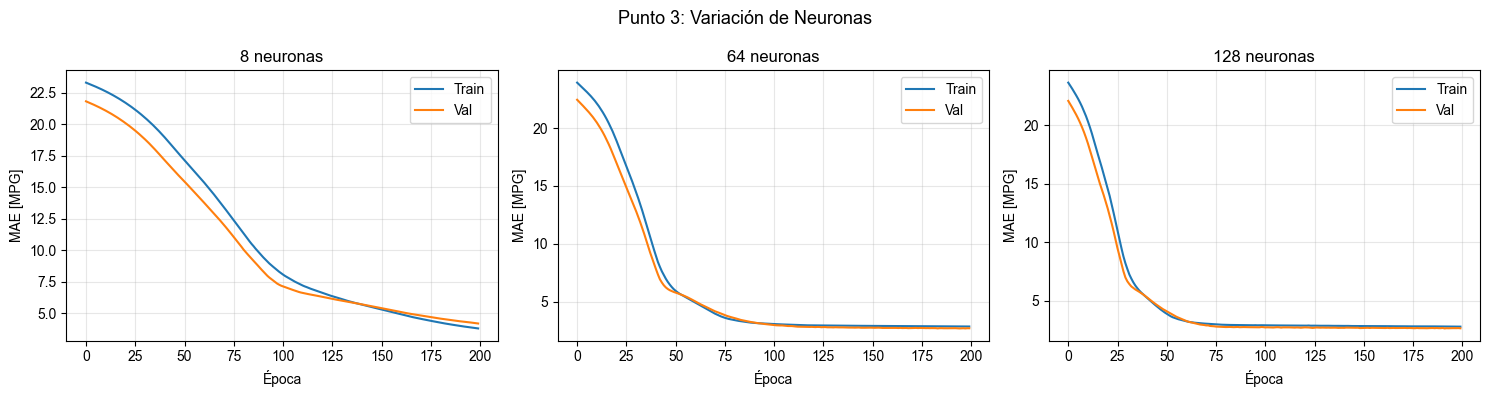

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, hist) in zip(axes, histories_neurons.items()):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(f'{name}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MAE [MPG]')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Punto 3: Variación de Neuronas', fontsize=13)
plt.tight_layout()
plt.show()

## Punto 4. 

Modifique el número de capas (3 casos diferentes al modelo base, puede cambiar también el número de neuronas en cada capa), entrene los modelos resultantes y compare. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte.

In [15]:
layer_configs = {
    '2 capas (8-4)': [
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(4, activation='relu'),
        tf.keras.layers.Dense(1)
    ],
    '3 capas (16-8-4)': [
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(4, activation='relu'),
        tf.keras.layers.Dense(1)
    ],
    '4 capas (64-32-16-8)': [
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1)
    ]
}

histories_layers = {}

for name, config in layer_configs.items():
    model, hist = build_and_train(config, name)
    histories_layers[name] = hist
    evaluate_model(model, f'Capas: {name}', results)

Capas: 2 capas (8-4)                     → MAE en test: 2.8701
Capas: 3 capas (16-8-4)                  → MAE en test: 21.3107
Capas: 4 capas (64-32-16-8)              → MAE en test: 2.7196


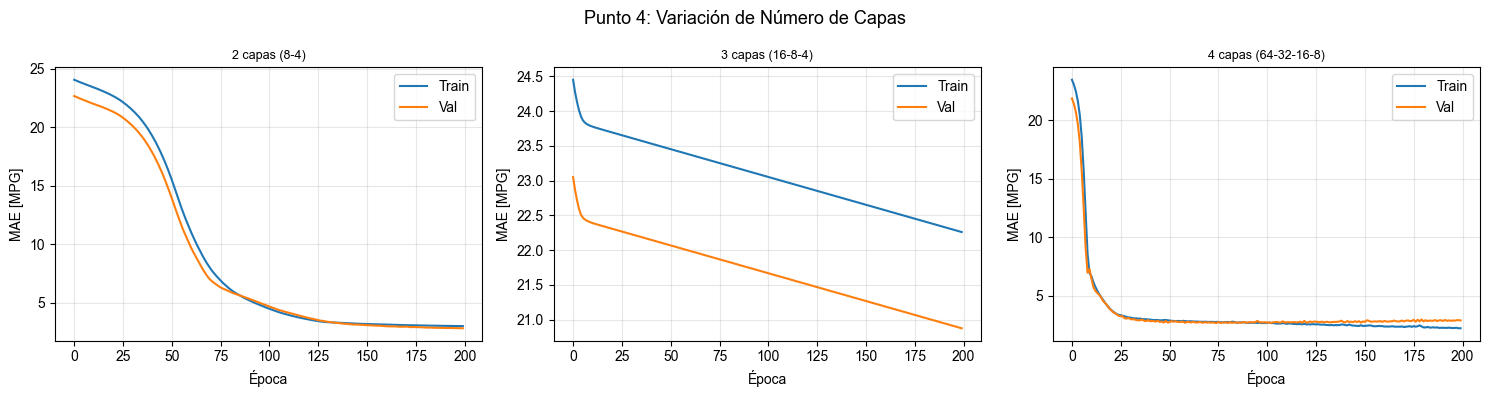

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, hist) in zip(axes, histories_layers.items()):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('MAE [MPG]')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Punto 4: Variación de Número de Capas', fontsize=13)
plt.tight_layout()
plt.show()

## Punto 5. 

Modifique las funciones de activación (3 casos diferentes al modelo base), entrene los modelos resultantes y compare. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte.

In [17]:
activation_configs = {
    'tanh': 'tanh',
    'sigmoid': 'sigmoid',
    'elu': 'elu'
}

histories_act = {}

for name, act in activation_configs.items():
    model, hist = build_and_train(
        [tf.keras.layers.Dense(32, activation=act),
         tf.keras.layers.Dense(1)],
        name
    )
    histories_act[name] = hist
    evaluate_model(model, f'Activación: {name}', results)

Activación: tanh                         → MAE en test: 3.0743
Activación: sigmoid                      → MAE en test: 3.0712
Activación: elu                          → MAE en test: 2.7657


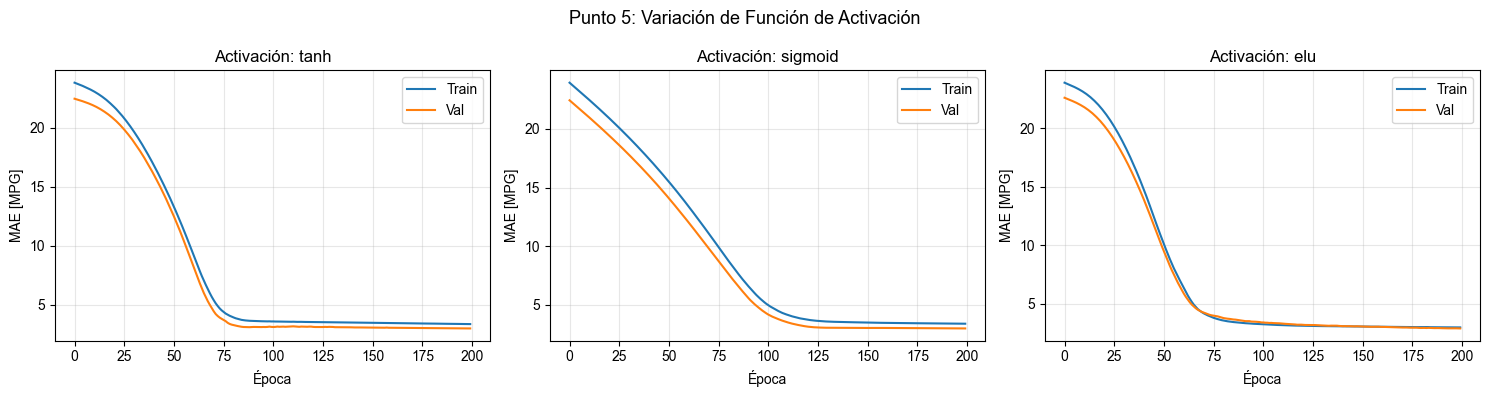

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, hist) in zip(axes, histories_act.items()):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(f'Activación: {name}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MAE [MPG]')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Punto 5: Variación de Función de Activación', fontsize=13)
plt.tight_layout()
plt.show()

## Punto 6.

A partir de los resultados anteriores proponga y evalée 2 modelos diferentes al modelo base y comp´arelos. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte.